In [1]:
import refinitiv.data as rd
import pandas as pd
from datetime import date, timedelta, datetime
import numpy as np
import matplotlib.pyplot as plt
import numpy_financial as npf
from scipy.optimize import brentq
import math
from tqdm import tqdm # to see progress

In [2]:
key7 = 'afa544907ced4690b75ab2e31be66bc5af09caa9'
key8 = '774f340989704932aa5c85967cfacd8c1c06642d'
key = key8
rd.open_session(app_key=key)

<refinitiv.data.session.Definition object at 0x1ee2cda3b00 {name='workspace'}>

# YTM Functions

In [3]:
def gen_date_range(start_date, end_date, step_days):
    date_range = pd.date_range(
        start=start_date,
        end=end_date,
        freq=pd.DateOffset(days=step_days)
    )
    return date_range

def calc_xirr(cash_flows, dates, year_convention=360.0): # excel uses the 365 day convention
    '''
    cash_flows must be a list of the cash amounts in date order (negative for outflow)
    dates must be a list of timestamps that represent the inflow or outflow of the cash_flows list, it must be the same length
    '''

    dates = pd.to_datetime(dates)
    t0 = dates[0] #investment date

    # convert each date into a year fraction from t0
    times = [(d - t0).days / year_convention for d in dates]

    # define the npv function
    # this computes present value of all cash flows
    # discounted at the given rate
    def npv(rate):
        return sum(cf / (1 + rate)**t for cf, t in zip(cash_flows, times))
    
    # solve for the rate that makes npv = 0
    # search between -99% and 500% annual yield
    return brentq(npv, -0.99, 5.0)

def calc_clean_price(price, coupon, coupon_days_freq, issue_date, maturity_date, face_v=100):
    today = pd.Timestamp.today().normalize()
    coupon_money = (face_v * coupon/100) * (coupon_days_freq/360)

    coupon_dates = gen_date_range(issue_date, maturity_date, coupon_days_freq)
    previous_coupon_date = coupon_dates[coupon_dates <= today].max()

    # the price from refinitiv is already the dirty price
    days_since_last_c = (today - previous_coupon_date).days
    acc_int = coupon_money * (days_since_last_c / coupon_days_freq)
    clean_price = price - acc_int
    
    return clean_price

def calc_ytm(price, coupon, coupon_days_freq, issue_date, maturity_date, face_v=100):
    today = pd.Timestamp.today().normalize()

    coupon_money = (face_v * coupon/100) * (coupon_days_freq/360)

    coupon_dates = gen_date_range(issue_date, maturity_date, coupon_days_freq) # generate the coupon payment dates

    if today in coupon_dates:
        # if today is a coupon date 
        cash_flow_dates = []
        cash_flows = [-price]

        for date in coupon_dates[coupon_dates > today]:
            cash_flow_dates.append(date)
            cash_flows.append(coupon_money)
        
        cash_flows[-1] = cash_flows[-1] + face_v # adding principal
        ytm = npf.irr(cash_flows) 
        return ytm * (360 / coupon_days_freq), cash_flows, cash_flow_dates

    else:
        # the price from refinitiv is the flat price
        # dirty price
        previous_coupon_date = coupon_dates[coupon_dates <= today].max()
        days_since_last_c = (today - previous_coupon_date).days
        acc_int = coupon_money * (days_since_last_c / coupon_days_freq)
        dirty_price = price + acc_int

        cash_flow_dates = [today]
        cash_flows = [-dirty_price]
        
        for date in coupon_dates[coupon_dates > today]:
            cash_flow_dates.append(date)
            cash_flows.append(coupon_money)
        
        cash_flows[-1] = cash_flows[-1] + face_v # adding principal
        
        ytm = calc_xirr(cash_flows, cash_flow_dates)
        return ytm, cash_flows, cash_flow_dates

In [4]:
#Using a Refinitiv SCREEN() expression to retrieve the universe of active tickers in the mx
screener = (
    'SCREEN('
      'U(IN(Equity(active,public,primary))/*UNV:Public*/), '
      # country
      'TR.ExchangeCountryCode = "MX"'
    ')'
)

# the data i want to gather (will be useful to do further screening)
fields = [
    'TR.CommonName',
    'TR.ISIN',
    'TR.CompanyMarketCap(Scale=0)',
    'TR.ExchangeName',
    'TR.TRBCEconomicSector',
    'TR.TRBCIndustryGroup',
    'TR.AssetCategory',
    'TR.FirstTradeDate'
]

screener_mx = rd.get_data(screener, fields)
screener_mx

C:\Users\Ramon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\refinitiv\data\_tools\_dataframe.py:192:FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


,Instrument,Company Common Name,ISIN,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
0,MINSAB.MX,Grupo Minsa SAB de CV,MXP510501119,3471994159.8,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,1997-05-16
1,GMD.MX,Grupo Mexicano de Desarrollo SAB,MX01GM080002,1277352944.0,Bolsa Mexicana de Valores S.A. de C.V.,Industrials,Construction & Engineering,Ordinary Share,1993-12-20
2,VALUEGFO.MX,Value Grupo Financiero SAB de CV,MXP800761019,10878400000.0,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Investment Banking & Investment Services,Ordinary Share,1992-12-11
3,EDOARDOB.MX,Edoardos Martin SAB de CV,MXP310341013,48553101.6,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Textiles & Apparel,Ordinary Share,1990-03-19
4,QBINDUSA.MX,QB Industrias SA de CV,MXP793911019,1468267483.2,Bolsa Mexicana de Valores S.A. de C.V.,Basic Materials,Chemicals,Ordinary Share,1992-07-15
...,...,...,...,...,...,...,...,...,...
147,GLOBCA.MX,Tenedora de Acciones CM SA de CV,MX1SGL050004,6575249143.8,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Banking Services,Ordinary Share,2024-02-28
148,DIABLOSA.MX,Diablos Rojos del Mexico SAPIB de CV,MX1SDI2B0004,2037290950.0,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Hotels & Entertainment Services,Ordinary Share,NaT
149,NEXT25.MX,Fideicomiso Irrevocable No 7401,MXCFNE040015,38455551036.0,Bolsa Mexicana de Valores S.A. de C.V.,Real Estate,Residential & Commercial REITs,Ordinary Share,2025-07-24
150,NUTRISAA.MX,Nutrisa SA de CV,MX01NU070004,1341139412.22,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,2025-09-18


In [6]:
screener_mx['Asset Category Description'].value_counts()

Asset Category Description
Ordinary Share                                133
Mexican Ordinary Participation Certificate      8
Equity ETF                                      7
Bond ETF                                        2
Unit                                            2
Name: count, dtype: Int64

In [7]:
filtered_screener_mx = screener_mx[screener_mx['Asset Category Description'].isin(['Ordinary Share', 'Mexican Ordinary Participation Certificate', 'Unit'])]
filtered_screener_mx

,Instrument,Company Common Name,ISIN,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
0,MINSAB.MX,Grupo Minsa SAB de CV,MXP510501119,3471994159.8,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,1997-05-16
1,GMD.MX,Grupo Mexicano de Desarrollo SAB,MX01GM080002,1277352944.0,Bolsa Mexicana de Valores S.A. de C.V.,Industrials,Construction & Engineering,Ordinary Share,1993-12-20
2,VALUEGFO.MX,Value Grupo Financiero SAB de CV,MXP800761019,10878400000.0,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Investment Banking & Investment Services,Ordinary Share,1992-12-11
3,EDOARDOB.MX,Edoardos Martin SAB de CV,MXP310341013,48553101.6,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Textiles & Apparel,Ordinary Share,1990-03-19
4,QBINDUSA.MX,QB Industrias SA de CV,MXP793911019,1468267483.2,Bolsa Mexicana de Valores S.A. de C.V.,Basic Materials,Chemicals,Ordinary Share,1992-07-15
...,...,...,...,...,...,...,...,...,...
147,GLOBCA.MX,Tenedora de Acciones CM SA de CV,MX1SGL050004,6575249143.8,Bolsa Mexicana de Valores S.A. de C.V.,Financials,Banking Services,Ordinary Share,2024-02-28
148,DIABLOSA.MX,Diablos Rojos del Mexico SAPIB de CV,MX1SDI2B0004,2037290950.0,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Cyclicals,Hotels & Entertainment Services,Ordinary Share,NaT
149,NEXT25.MX,Fideicomiso Irrevocable No 7401,MXCFNE040015,38455551036.0,Bolsa Mexicana de Valores S.A. de C.V.,Real Estate,Residential & Commercial REITs,Ordinary Share,2025-07-24
150,NUTRISAA.MX,Nutrisa SA de CV,MX01NU070004,1341139412.22,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Tobacco,Ordinary Share,2025-09-18


In [8]:
filtered_screener_mx[filtered_screener_mx['Instrument'] == 'FEMSAUBD.MX']

,Instrument,Company Common Name,ISIN,Company Market Cap,Exchange Name,TRBC Economic Sector Name,TRBC Industry Group Name,Asset Category Description,First Trade Date
118,FEMSAUBD.MX,Fomento Economico Mexicano SAB de CV,MXP320321310,614725063798.599976,Bolsa Mexicana de Valores S.A. de C.V.,Consumer Non-Cyclicals,Food & Drug Retailing,Unit,1991-04-01


In [9]:
ticker_names = list(filtered_screener_mx['Instrument'])
ticker_names

['MINSAB.MX',
 'GMD.MX',
 'VALUEGFO.MX',
 'EDOARDOB.MX',
 'QBINDUSA.MX',
 'TEKCHEMA.MX',
 'COLLADO.MX',
 'IASASA.MX',
 'ACCELSAB.MX',
 'CIDMEGA.MX',
 'DINEB.MX',
 'CHDRAUIB.MX',
 'ACTINVRB.MX',
 'TEAKCPO.MX',
 'CONVERA.MX',
 'SPORTS.MX',
 'GENTERA.MX',
 'MFRISCOA1.MX',
 'RA.MX',
 'ALPEKA.MX',
 'VESTA.MX',
 'Q.MX',
 'PV.MX',
 'CREAL.MX',
 'FIHO12.MX',
 'HCITY.MX',
 'VOLARA.MX',
 'FIBRAPL14.MX',
 'HOTEL.MX',
 'AGUA.MX',
 'UNIFINA.MX',
 'GICSAB.MX',
 'NEMAKA.MX',
 'RLHA.MX',
 'CADUA.MX',
 'LACOMERUBC.MX',
 'PLANI.MX',
 'VINTE.MX',
 'FVIA16.MX',
 'FPLUS16.MX',
 'CUERVO.MX',
 'BBAJIOO.MX',
 'VISTAA.MX',
 'TRAXIONA.MX',
 'INFRAEX18.MX',
 'FCFE182.MX',
 'BAFARB.BIV',
 'LASITE.MX',
 'XFRA22.MX',
 'SITES1A1.MX',
 'FEXI21.MX',
 'FORION20.MX',
 'GAVA.MX',
 'COXA.MX',
 'FIDEAL20.MX',
 'AGRIEXPA.MX',
 'ALSEA.MX',
 'ARISTOSA.MX',
 'ARA.MX',
 'AC.MX',
 'AUTLANB.MX',
 'AHMSA.MX',
 'SIGMAFA.MX',
 'ASURB.MX',
 'AXTELCPO.MX',
 'CYDSASAA.MX',
 'FINAMEXO.MX',
 'BIMBOA.MX',
 'GCARSOA1.MX',
 'GFMULTIO.MX',
 

# Getting subsidiares

Some companies in Mexico use subsidiaries to issue bonds.

In [10]:
data = rd.get_data(
    universe=['AC.MX'],
    fields=['TR.RelatedOrgId', 'TR.RelatedOrgName', 'TR.RelatedOrgType'])

data

,Instrument,Related OrgId,Related Org Name,Related Org Type
0,AC.MX,5000434704,Petstar SA de CV,Affiliate
1,AC.MX,4295884351,Arca Continental SAB de CV,Subsidiary
2,AC.MX,5036860809,Holding Tonicorp SA,Subsidiary
3,AC.MX,4295990648,Embotelladora Aguascalientes SA de CV,Subsidiary
4,AC.MX,4295990662,Embotelladora Zacatecas SA de CV,Subsidiary
...,...,...,...,...
65,AC.MX,5071083909,Vending del Ecuador SA,Subsidiary
66,AC.MX,5071084031,Servicios Ejecutivos Arca Continental SA de CV,Subsidiary
67,AC.MX,5071084034,AC Bebidas Ecuador S de R L de CV,Subsidiary
68,AC.MX,5083871926,Productora Y Comercializadora De Bebidas Arca ...,Subsidiary


In [11]:
subsidiaries_by_ticker = {}
no_subsidiares_ticker = []

for ticker in tqdm(ticker_names):
    try:
        data = rd.get_data(
            universe=[ticker],
            fields=['TR.RelatedOrgId', 'TR.RelatedOrgName', 'TR.RelatedOrgType']
        )

        if data.empty:
            no_subsidiares_ticker.append(ticker)
        else:
            subsidiaries_by_ticker[ticker] = list(data['Related Org Name'])
    
    except Exception as e:
        print(f'Error with {ticker}: {e}')

100%|██████████| 143/143 [04:22<00:00,  1.84s/it]


In [ ]:
# some tickers have blank spaces in the column 'Related Org Name' for the subsidiaries, i should drop that before doing anything

In [12]:
no_subsidiares_ticker

[]

In [14]:
subsidiaries_by_ticker['AC.MX']

['Petstar SA de CV',
 'Arca Continental SAB de CV',
 'Holding Tonicorp SA',
 'Embotelladora Aguascalientes SA de CV',
 'Embotelladora Zacatecas SA de CV',
 'Embotelladora La Favorita SA de CV',
 'Industrial de Plasticos Arma SA de CV',
 'Wise Foods Inc',
 'Embotelladora Guadiana SA de CV',
 'Embotelladora San Luis SA de CV',
 'Embotelladora Zapopan SA de CV',
 'Compania Topo Chico SA de CV',
 'Embotelladora Internacional SA',
 'Nacional de Alimentos y Helados SA de CV',
 'Productora y Comercializadora de Bebidas Arca SA de CV',
 'Embotelladora los Altos SA de CV',
 'Interex Corp',
 'Formosa Refrescos SA',
 'Old Lyme Gourmet Co',
 'Sociedad Industrial SA de CV',
 'Procesos Estandarizados Administrativos SA de CV',
 'Desarrolladora Arca SA de CV',
 'Servicios Corporativos Arca SA de CV',
 'Rockfalls Spain SL',
 'Embotelladoras Arca de Argentina S A',
 'Distribuidora Dico SA',
 'Salta Refrescos SA',
 'Salta Refrescos SA',
 'Envases Plasticos SAIC',
 'Arca Ecuador SA',
 'Industrial de Gase

In [13]:
company_names = filtered_screener_mx['Company Common Name']
subsidiaries_series = pd.Series([s for lst in subsidiaries_by_ticker.values() for s in lst])

company_and_subsidiaries_names = pd.concat([company_names, subsidiaries_series], ignore_index=True)


In [14]:
company_and_subsidiaries_names.to_pickle("company_and_subsidiaries.pkl")

In [15]:
company_and_subsidiaries_names = pd.read_pickle("company_and_subsidiaries.pkl")

In [16]:
company_and_subsidiaries_names = list(company_and_subsidiaries_names.dropna())

In [17]:
len(company_and_subsidiaries_names)

2844

In [18]:
today = pd.Timestamp.today().normalize()

In [ ]:
bonds_data_df = rd.discovery.search(
    view = rd.discovery.Views.FIXED_INCOME_INSTRUMENTS,
    filter = f"IssuerCommonName eq 'Value Arrendadora SA de CV SOFOM ER Value Grupo Financiero'",
    top = 1000,
    select='RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency'
)

bonds_data_df = bonds_data_df[bonds_data_df['MaturityDate'] > today]

In [76]:
bonds_data_df

,RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency
0,MX91VA2600J3=VALR,MX91VA2600J3,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-04-16,2029-04-10,9.68,1000000000,MXN
1,MX91VA2600K1=VALR,MX91VA2600K1,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-06-20,2029-06-14,9.75,500000000,MXN
2,MX91VA2600L9=VALR,MX91VA2600L9,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2024-10-15,2029-10-09,9.75,500000000,MXN
3,MX91VA2600M7=VALR,MX91VA2600M7,Value Arrendadora SA de CV SOFOM ER Value Grup...,Value Arrendadora SA de CV SOFOM ER Value Grup...,2025-07-24,2030-07-18,8.65,1000000000,MXN


In [ ]:
company_names_upper = [c.upper() for c in company_names]
company_names_upper

In [19]:
dfs = []
comp_bond_data = []
comp_no_bond_data = []
error_company = {}

for company in tqdm(company_and_subsidiaries_names): #mininterval= can help reduce overhead. default is .1 s
    try:
        company_bonds_data_df = rd.discovery.search(
            view = rd.discovery.Views.FIXED_INCOME_INSTRUMENTS,
            filter = f"IssuerCommonName eq '{company}'",
            top = 1000,
            select='ISIN,IssuerCommonName,DocumentTitle,MaturityDate,CouponRate,Currency')
    
        if company_bonds_data_df.empty:
            comp_no_bond_data.append(company)
            continue

        else:
            comp_bond_data.append(company)
            dfs.append(company_bonds_data_df)

    except Exception as e:
        print(f'Error with {company}: {e}')
        error_company[company] = e

# concatenate all dfs
final_bonds_df = pd.concat(dfs, ignore_index=True)

 18%|█▊        | 512/2844 [03:39<13:11,  2.95it/s]

Error with Cibalis SA de CV: Error code 503 | <html>
<head><title>503 Service Temporarily Unavailable</title></head>
<body>
<center><h1>503 Service Temporarily Unavailable</h1></center>
</body>
</html>
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->
<!-- a padding to disable MSIE and Chrome friendly error page -->



 35%|███▍      | 990/2844 [07:06<12:08,  2.54it/s]

Error with Emmy's Organics LLC: Error code 400 | Invalid filter: unexpected <s> immediately after string <'Emmy'> (hint: escape literal <'> as <''>)


 36%|███▋      | 1033/2844 [07:24<12:46,  2.36it/s]

Error with : Error code 400 | Invalid filter: empty strings have no meaning; to express 'no value', use null


100%|█████████▉| 2843/2844 [20:33<00:00,  2.09it/s]

Error with : Error code 400 | Invalid filter: empty strings have no meaning; to express 'no value', use null


100%|██████████| 2844/2844 [20:34<00:00,  2.30it/s]

Error with : Error code 400 | Invalid filter: empty strings have no meaning; to express 'no value', use null


In [ ]:
# the other thing i can do is to gather all the bond data and once i have the full df then i filter by maturitydate to have only the active bonds

In [20]:
final_bonds_df

,ISIN,IssuerCommonName,DocumentTitle,MaturityDate,CouponRate,Currency
0,MX93MI080140,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-03-12,7.55,MXN
1,MX93MI080157,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-04-23,7.76,MXN
2,MX93MI080165,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-05-28,7.76,MXN
3,MX93MI080173,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-06-18,7.46,MXN
4,MX93MI080181,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-07-09,7.15,MXN
...,...,...,...,...,...,...
9490,US05462GAA22,Axtel SAB de CV,"Axtel SAB de CV, Plain Vanilla Fixed Coupon Bo...",2017-02-01,7.625,USD
9491,US05462GAE44,Axtel SAB de CV,"Axtel SAB de CV, Step Up / Step Down Bond, TRA...",2020-01-31,9.0,USD
9492,US05462GAJ31,Axtel SAB de CV,"Axtel SAB de CV, Plain Vanilla Fixed Coupon Bo...",2024-11-14,6.375,USD
9493,US05461YAB20,Axtel SAB de CV,"Axtel SAB de CV, Plain Vanilla Fixed Coupon Bo...",2013-12-15,11.0,USD


In [21]:
error_company

{'Cibalis SA de CV': refinitiv.data._errors.RDError(503,
                                '<html>\r\n<head><title>503 Service Temporarily Unavailable</title></head>\r\n<body>\r\n<center><h1>503 Service Temporarily Unavailable</h1></center>\r\n</body>\r\n</html>\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n<!-- a padding to disable MSIE and Chrome friendly error page -->\r\n'),
 "Emmy's Organics LLC": refinitiv.data._errors.RDError(400,
                                "Invalid filter: unexpected <s> immediately after string <'Emmy'> (hint: escape literal <'> as <''>)"),
 '': refinitiv.data._errors.RDError(400,
                                "Invalid filter: empty strings have no meaning; t

In [23]:
final_bonds_df.dtypes

ISIN                string[python]
IssuerCommonName    string[python]
DocumentTitle       string[python]
MaturityDate        datetime64[ns]
CouponRate                 Float64
Currency            string[python]
dtype: object

In [22]:
today = pd.Timestamp.today().normalize()
final_bonds_df = final_bonds_df[final_bonds_df['MaturityDate'] > today]
final_bonds_df = final_bonds_df[final_bonds_df['Currency'] == 'MXN']
final_bonds_df

,ISIN,IssuerCommonName,DocumentTitle,MaturityDate,CouponRate,Currency
0,MX93MI080140,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-03-12,7.55,MXN
1,MX93MI080157,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-04-23,7.76,MXN
2,MX93MI080165,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-05-28,7.76,MXN
3,MX93MI080173,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-06-18,7.46,MXN
4,MX93MI080181,Grupo Minsa SAB de CV,"Grupo Minsa SAB de CV, Commercial Paper, MINSA...",2026-07-09,7.15,MXN
...,...,...,...,...,...,...
8733,XS0278859771,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2036-12-18,8.46,MXN
8734,XS0278906440,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2036-12-18,8.46,MXN
8735,XS0329579600,America Movil SAB de CV,"America Movil SAB de CV, Plain Vanilla Fixed C...",2036-12-18,8.46,MXN
8745,<NA>,America Movil SAB de CV,"America Movil SAB de CV, Commercial Paper, AMX...",2026-05-14,0.0,MXN


In [25]:
final_bonds_df['IssuerCommonName'].value_counts()

IssuerCommonName
America Movil SAB de CV                                                    92
INVEX Grupo Financiero SA de CV                                            55
Banco Multiva SA Institucion de Banca Multiple Grupo Financiero Multiva    43
Genomma Lab Internacional SAB de CV                                        42
Grupo Financiero Banorte SAB de CV                                         32
Grupo Aeroportuario del Pacifico SAB de CV                                 28
Grupo Bimbo SAB de CV                                                      16
Banco Compartamos SA Institucion de Banca Multiple                         16
Coca-Cola Femsa SAB de CV                                                  16
Grupo Aeroportuario del Centro Norte SAB de CV                             16
Grupo Televisa SAB                                                         14
Vinte Viviendas Integrales SAB de CV                                       14
Grupo Elektra SAB de CV                        

In [23]:
final_bonds_df.isna().sum()

ISIN                20
IssuerCommonName     0
DocumentTitle        0
MaturityDate         0
CouponRate           0
Currency             0
dtype: int64

In [24]:
final_bonds_df = final_bonds_df.dropna(subset=['ISIN'])
final_bonds_df.isna().sum()

ISIN                0
IssuerCommonName    0
DocumentTitle       0
MaturityDate        0
CouponRate          0
Currency            0
dtype: int64

In [25]:
isin_bonds_series = final_bonds_df['ISIN']
isin_bonds_series

0       MX93MI080140
1       MX93MI080157
2       MX93MI080165
3       MX93MI080173
4       MX93MI080181
            ...     
8730    XS2701559440
8733    XS0278859771
8734    XS0278906440
8735    XS0329579600
9115    MX91TE000071
Name: ISIN, Length: 566, dtype: string

In [26]:
isin_bonds_series.to_pickle("isin_mx_active_bonds_mar2026.pkl")

In [27]:
isin_bonds_series = pd.read_pickle("isin_mx_active_bonds_mar2026.pkl")

In [28]:
isin_bonds = list(isin_bonds_series)

In [29]:
len(isin_bonds)

566

In [30]:
fields_bonds = ['TR.FiIssuerName','TR.UltimateParent', 'TR.TRBCEconomicSector','TR.TRBCBusinessSector','TR.TRBCIndustryGroup',
                'TR.FiParValue','TR.FIPrice','TR.CLEANPRICE','TR.DIRTYPRICE','TR.CA.AmtOutstanding',"TR.CouponRate",
                'TR.FiCouponType','TR.InterestFormula','TR.FRNFORMULA','TR.FiCouponFrequency','TR.FiCouponFrequencyDescription',
                'TR.FiIssueDate','TR.FiMaturityDate','TR.IssuerRating','TR.IR.RatingSourceDescription','TR.FiIssuerFitchLongRating',
                'TR.FiIssuerMoodysLongRating','TR.FiLiquidationRank','TR.FiSeniorityType','TR.FiSeniorityTypeDescription','TR.FiIsCallable',
                'TR.FiIsStraight','TR.YieldToCallDateAnalytics','TR.FINextCallDate','TR.FiCallPrice','TR.FINextCallPrice',
                'TR.YieldToCallAnalytics', 'TR.YieldToWorstAnalytics','TR.FiMaturityStandardYield','TR.FiESGBondFlag','TR.FiESGBondType',
                'TR.TRESGScoreGrade']

In [31]:
isin_bonds

['MX93MI080140',
 'MX93MI080157',
 'MX93MI080165',
 'MX93MI080173',
 'MX93MI080181',
 'MX91AC0Q00F2',
 'MX91AC0Q00G0',
 'MX93MF010231',
 'MX91MF010043',
 'MX91MF010050',
 'MX91AG050018',
 'MX91GI020005',
 'MX91GI020054',
 'MX91GI020039',
 'MX91VI050086',
 'MX91VI050052',
 'MX91VI050094',
 'MX91VI0500A9',
 'MX91VI0500D3',
 'MX91VI0500B7',
 'MX91VI0500C5',
 'MX0FBB0002T2',
 'MX0FBB0002U0',
 'MX93TR0H00F1',
 'MX93TR0H00E4',
 'MX91TR0H0007',
 'MX91TR0H0015',
 'MX91TR0H0023',
 'MX91SI0C0003',
 'MX91SI0C0011',
 'MX91AL2F00A1',
 'MX91AL2F0075',
 'MX91AR1C0035',
 'MX91AR1C0027',
 'MX91AC100049',
 'MX91AC100064',
 'MX91AC100056',
 'MX91AC100072',
 'MX91CY000001',
 'MX91CY000019',
 'MX91BI0Y00A0',
 'MX91BI0Y0086',
 'MX91BI0Y0094',
 'MX91BI0Y00D4',
 'MX91BI0Y00E2',
 'MX91BI0Y00C6',
 'MX91BI0Y00B8',
 'MX91BI0Y00F9',
 'MX91GC000078',
 'MX91GC000086',
 'MX91GC000094',
 'MX91CI010075',
 'MX91GI000031',
 'MX91EL0000R4',
 'MX91EL0000Q6',
 'MX91EL0000D4',
 'MX91EL0000H5',
 'MX91EL0000L7',
 'MX91EL0000P8

In [32]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

dfs = []
error_isins = []

for isin in tqdm(isin_bonds, mininterval=1):
    try:
        bond_data = rd.get_data(
            universe=[isin],
            fields=fields_bonds)

        dfs.append(bond_data)

    except Exception as e:
        error_isins.append(isin)
        print(f'Error with {isin}: {e}')

bonds_data_df1 = pd.concat(dfs, ignore_index=True)

 76%|███████▌  | 430/566 [32:52<23:48, 10.51s/it]  

Error with MX0IBA052U20: Error code -1 | Backend error. 400 Bad Request Requested universes: ['MX0IBA052U20']. Requested fields: ['TR.FIISSUERNAME', 'TR.ULTIMATEPARENT', 'TR.TRBCECONOMICSECTOR', 'TR.TRBCBUSINESSSECTOR', 'TR.TRBCINDUSTRYGROUP', 'TR.FIPARVALUE', 'TR.FIPRICE', 'TR.CLEANPRICE', 'TR.DIRTYPRICE', 'TR.CA.AMTOUTSTANDING', 'TR.COUPONRATE', 'TR.FICOUPONTYPE', 'TR.INTERESTFORMULA', 'TR.FRNFORMULA', 'TR.FICOUPONFREQUENCY', 'TR.FICOUPONFREQUENCYDESCRIPTION', 'TR.FIISSUEDATE', 'TR.FIMATURITYDATE', 'TR.ISSUERRATING', 'TR.IR.RATINGSOURCEDESCRIPTION', 'TR.FIISSUERFITCHLONGRATING', 'TR.FIISSUERMOODYSLONGRATING', 'TR.FILIQUIDATIONRANK', 'TR.FISENIORITYTYPE', 'TR.FISENIORITYTYPEDESCRIPTION', 'TR.FIISCALLABLE', 'TR.FIISSTRAIGHT', 'TR.YIELDTOCALLDATEANALYTICS', 'TR.FINEXTCALLDATE', 'TR.FICALLPRICE', 'TR.FINEXTCALLPRICE', 'TR.YIELDTOCALLANALYTICS', 'TR.YIELDTOWORSTANALYTICS', 'TR.FIMATURITYSTANDARDYIELD', 'TR.FIESGBONDFLAG', 'TR.FIESGBONDTYPE', 'TR.TRESGSCOREGRADE']


100%|██████████| 566/566 [41:49<00:00,  4.43s/it]


In [33]:
len(error_isins)

1

In [34]:
bonds_data_df1

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,Yield to Call Date,Call Date,Call Price,Call Price,Yield to Call,Yield to Worst,Yield To Maturity,ESG Bond Flag,ESG Bond Type,ESG Score Grade
0,MX93MI080140,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,100.000336,100.314919,...,NaT,NaT,,,<NA>,0.453194,,N,,
1,MX93MI080157,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,100.017158,100.49138,...,NaT,NaT,,,<NA>,5.673071,,N,,
2,MX93MI080165,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,100.026505,100.500727,...,NaT,NaT,,,<NA>,6.36158,,N,,
3,MX93MI080173,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,99.994212,100.305045,...,NaT,NaT,,,<NA>,6.848119,,N,,
4,MX93MI080181,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,99.994589,100.294172,...,NaT,NaT,,,<NA>,6.720969,,N,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,10000,107.285,107.456,108.3716,...,2033-10-31,2033-10-30,100,100,8.915141,8.915141,8.985971,Y,Sustainability Bond,B
561,XS0278859771,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.874,88.874,90.6365,...,NaT,NaT,,,<NA>,10.069599,10.170137,N,,B
562,XS0278906440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.8733,,,...,NaT,NaT,,,<NA>,10.069781,10.170008,N,,B
563,XS0329579600,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.874,88.874,90.6365,...,NaT,NaT,,,<NA>,10.069599,10.170137,N,,B


In [35]:
bonds_data_df1.isna().sum()

Instrument                        0
Issuer Name                       0
Organization Ultimate Parent      0
TRBC Economic Sector Name         0
TRBC Business Sector Name         0
TRBC Industry Group Name          0
Par Value                         0
Price                             0
Clean Price                       5
Dirty Price                       7
Amount Outstanding                0
Coupon Rate                       0
Coupon Type                       0
Interest Formula                  0
FRN Formula                       0
Coupon Frequency                  0
Coupon Frequency Description      0
Issue Date                        0
Maturity Date                     0
Issuer Rating                     0
Rating Source Description         0
Issuer Fitch Long Rating          0
Issuer Moodys Long Rating         0
Liquidation Rank                  0
Seniority Type                    0
Seniority Type Description        0
Is Callable                       0
Is Straight                 

In [ ]:
error_isins_retry = error_isins.copy()

dfs = []
error_isins = []

for isin in tqdm(error_isins_retry, mininterval=1):
    try:
        bond_data = rd.get_data(
            universe=[isin],
            fields=fields_bonds)
        
        dfs.append(bond_data)

    except Exception as e:
        error_isins.append(isin)
        print(f'Error with {isin}: {e}')

bonds_data_df2 = pd.concat(dfs, ignore_index=True)

In [40]:
bonds_data_df2

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,Yield to Call Date,Call Date,Call Price,Call Price,Yield to Call,Yield to Worst,Yield To Maturity,ESG Bond Flag,ESG Bond Type,ESG Score Grade
0,MX0IBA052U20,INVEX GRUPO FINANCIERO SA DE CV,Invex Controladora SAB de CV,Financials,Banking & Investment Services,Banking Services,1,,,,...,NaT,NaT,,,<NA>,0,,N,,


In [41]:
final_bonds_data_df = pd.concat([bonds_data_df1, bonds_data_df2], ignore_index=True)

In [42]:
final_bonds_data_df = bonds_data_df1.copy()

In [43]:
final_bonds_data_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,Yield to Call Date,Call Date,Call Price,Call Price,Yield to Call,Yield to Worst,Yield To Maturity,ESG Bond Flag,ESG Bond Type,ESG Score Grade
0,MX93MI080140,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,100.000336,100.314919,...,NaT,NaT,,,<NA>,0.453194,,N,,
1,MX93MI080157,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,100.017158,100.49138,...,NaT,NaT,,,<NA>,5.673071,,N,,
2,MX93MI080165,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,100.026505,100.500727,...,NaT,NaT,,,<NA>,6.36158,,N,,
3,MX93MI080173,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,99.994212,100.305045,...,NaT,NaT,,,<NA>,6.848119,,N,,
4,MX93MI080181,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,,99.994589,100.294172,...,NaT,NaT,,,<NA>,6.720969,,N,,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,10000,107.285,107.456,108.3716,...,2033-10-31,2033-10-30,100,100,8.915141,8.915141,8.985971,Y,Sustainability Bond,B
561,XS0278859771,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.874,88.874,90.6365,...,NaT,NaT,,,<NA>,10.069599,10.170137,N,,B
562,XS0278906440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.8733,,,...,NaT,NaT,,,<NA>,10.069781,10.170008,N,,B
563,XS0329579600,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.874,88.874,90.6365,...,NaT,NaT,,,<NA>,10.069599,10.170137,N,,B


In [44]:
final_bonds_data_df = final_bonds_data_df.replace('', np.nan)
final_bonds_data_df.isna().sum()

Instrument                        0
Issuer Name                       0
Organization Ultimate Parent      0
TRBC Economic Sector Name        14
TRBC Business Sector Name        14
TRBC Industry Group Name         14
Par Value                         0
Price                           451
Clean Price                     170
Dirty Price                     170
Amount Outstanding                0
Coupon Rate                       0
Coupon Type                       0
Interest Formula                324
FRN Formula                     324
Coupon Frequency                152
Coupon Frequency Description    152
Issue Date                        0
Maturity Date                     0
Issuer Rating                    63
Rating Source Description        63
Issuer Fitch Long Rating        276
Issuer Moodys Long Rating       322
Liquidation Rank                  0
Seniority Type                    0
Seniority Type Description        0
Is Callable                       0
Is Straight                 

In [45]:
final_bonds_data_df['days_to_maturity'] = final_bonds_data_df['Maturity Date'] - today
final_bonds_data_df['days_to_maturity'] = (final_bonds_data_df['days_to_maturity'].dt.total_seconds() / (24 * 3600)) #because it was a timedelta i had to convert it to seconds and then multiply
final_bonds_data_df['years_to_maturity'] = (final_bonds_data_df['days_to_maturity'] / 365.25)
final_bonds_data_df['final_flat_price'] = final_bonds_data_df['Clean Price'].fillna(final_bonds_data_df['Price'])
final_bonds_data_df

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,Call Price,Yield to Call,Yield to Worst,Yield To Maturity,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,final_flat_price
0,MX93MI080140,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,NaN,100.000336,100.314919,...,NaN,<NA>,0.453194,NaN,N,<NA>,<NA>,10.0,0.027379,100.000336
1,MX93MI080157,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,NaN,100.017158,100.491380,...,NaN,<NA>,5.673071,NaN,N,<NA>,<NA>,52.0,0.142368,100.017158
2,MX93MI080165,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,NaN,100.026505,100.500727,...,NaN,<NA>,6.36158,NaN,N,<NA>,<NA>,87.0,0.238193,100.026505
3,MX93MI080173,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,NaN,99.994212,100.305045,...,NaN,<NA>,6.848119,NaN,N,<NA>,<NA>,108.0,0.295688,99.994212
4,MX93MI080181,GRUPO MINSA SAB DE CV,Promotora Empresarial de Occidente SA de CV,Consumer Non-Cyclicals,Food & Beverages,Food & Tobacco,100,NaN,99.994589,100.294172,...,NaN,<NA>,6.720969,NaN,N,<NA>,<NA>,129.0,0.353183,99.994589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
560,XS2701559440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,10000,107.2850,107.456000,108.371600,...,100.0,8.915141,8.915141,8.985971,Y,Sustainability Bond,B,2891.0,7.915127,107.456000
561,XS0278859771,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.8740,88.874000,90.636500,...,NaN,<NA>,10.069599,10.170137,N,<NA>,B,3944.0,10.798084,88.874000
562,XS0278906440,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.8733,NaN,NaN,...,NaN,<NA>,10.069781,10.170008,N,<NA>,B,3944.0,10.798084,88.873300
563,XS0329579600,AMERICA MOVIL SAB DE CV,America Movil SAB de CV,Technology,Telecommunications Services,Telecommunications Services,100000,88.8740,88.874000,90.636500,...,NaN,<NA>,10.069599,10.170137,N,<NA>,B,3944.0,10.798084,88.874000


In [46]:
final_bonds_data_df.isna().sum()

Instrument                        0
Issuer Name                       0
Organization Ultimate Parent      0
TRBC Economic Sector Name        14
TRBC Business Sector Name        14
TRBC Industry Group Name         14
Par Value                         0
Price                           451
Clean Price                     170
Dirty Price                     170
Amount Outstanding                0
Coupon Rate                       0
Coupon Type                       0
Interest Formula                324
FRN Formula                     324
Coupon Frequency                152
Coupon Frequency Description    152
Issue Date                        0
Maturity Date                     0
Issuer Rating                    63
Rating Source Description        63
Issuer Fitch Long Rating        276
Issuer Moodys Long Rating       322
Liquidation Rank                  0
Seniority Type                    0
Seniority Type Description        0
Is Callable                       0
Is Straight                 

In [47]:
final_bonds_data_df['Issuer Name'].value_counts()

Issuer Name
AMERICA MOVIL SAB DE CV                                                    90
INVEX GRUPO FINANCIERO SA DE CV                                            52
GENOMMA LAB INTERNACIONAL SAB DE CV                                        38
BANCO MULTIVA SA INSTITUCION DE BANCA MULTIPLE GRUPO FINANCIERO MULTIVA    33
GRUPO FINANCIERO BANORTE SAB DE CV                                         30
GRUPO AEROPORTUARIO DEL PACIFICO SAB DE CV                                 28
GRUPO BIMBO SAB DE CV                                                      16
BANCO COMPARTAMOS SA INSTITUCION DE BANCA MULTIPLE                         16
COCA-COLA FEMSA SAB DE CV                                                  16
GRUPO AEROPORTUARIO DEL CENTRO NORTE SAB DE CV                             16
GRUPO TELEVISA SAB                                                         14
VINTE VIVIENDAS INTEGRALES SAB DE CV                                       14
GRUPO ELEKTRA SAB DE CV                             

In [48]:
final_bonds_data_df[final_bonds_data_df['Issuer Name'] == 'COCA-COLA FEMSA SAB DE CV']

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,Call Price,Yield to Call,Yield to Worst,Yield To Maturity,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,final_flat_price
121,MX91KO0000G8,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,100.52,99.967858,100.426802,...,NaN,<NA>,7.011902,7.422666,Y,Sustainability Linked Bond,A-,199.0,0.544832,99.967858
122,MX91KO0000I4,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,NaN,99.995239,100.076461,...,100.0,5.15585,5.15585,NaN,Y,Sustainability Bond,A-,217.0,0.594114,99.995239
123,MX91KO0000B9,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,102.22,NaN,NaN,...,NaN,<NA>,7.365334,7.348756,N,<NA>,A-,473.0,1.295003,102.220000
124,MX91KO0000D5,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,99.83,NaN,NaN,...,NaN,<NA>,7.612674,7.811275,N,<NA>,A-,697.0,1.908282,99.830000
125,MX91KO0000F0,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,103.04,99.669901,102.981901,...,NaN,<NA>,6.786838,7.511409,Y,Sustainability Linked Bond,A-,927.0,2.537988,99.669901
126,MX91KO0000K0,COCA-COLA FEMSA SAB DE CV,Porsche Automobil Holding SE,Financials,Banking & Investment Services,Banking Services,100,NaN,99.998160,99.998160,...,NaN,<NA>,7.518828,NaN,N,<NA>,<NA>,1078.0,2.951403,99.998160
127,MX91KO0000H6,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,NaN,106.430960,110.410960,...,100.0,-178.185452,-178.185452,NaN,Y,Social Bond,A-,1309.0,3.583847,106.430960
128,MX91KO0000J2,COCA-COLA FEMSA SAB DE CV,Mexico (United Mexican States) (Government),Energy,Energy - Fossil Fuels,Oil & Gas,100,NaN,100.000000,100.000000,...,NaN,<NA>,8.938639,NaN,N,<NA>,C,1863.0,5.100616,100.000000
469,MX91KO0000G8,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,100.52,99.967858,100.426802,...,NaN,<NA>,7.011902,7.422666,Y,Sustainability Linked Bond,A-,199.0,0.544832,99.967858
470,MX91KO0000I4,COCA-COLA FEMSA SAB DE CV,Fomento Economico Mexicano SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,NaN,99.995239,100.076461,...,100.0,5.15585,5.15585,NaN,Y,Sustainability Bond,A-,217.0,0.594114,99.995239


In [24]:
final_bonds_data_df.to_csv('mx_active_bonds_data_feb2026.csv')

In [58]:
final_bonds_data_df.columns

Index(['Instrument', 'Issuer Name', 'Organization Ultimate Parent',
       'TRBC Economic Sector Name', 'TRBC Business Sector Name',
       'TRBC Industry Group Name', 'Par Value', 'Price', 'Clean Price',
       'Dirty Price', 'Amount Outstanding', 'Coupon Rate', 'Coupon Type',
       'Interest Formula', 'FRN Formula', 'Coupon Frequency',
       'Coupon Frequency Description', 'Issue Date', 'Maturity Date',
       'Issuer Fitch Long Rating', 'Issuer Moodys Long Rating',
       'Liquidation Rank', 'Seniority Type', 'Seniority Type Description',
       'Is Callable', 'Is Straight', 'Yield to Call Date', 'Call Date',
       'Call Price', 'Call Price', 'Yield to Call', 'Yield to Worst',
       'Yield To Maturity', 'ESG Bond Flag', 'ESG Bond Type',
       'ESG Score Grade', 'days_to_maturity', 'years_to_maturity'],
      dtype='object')

# Bonos Mexico Data

In [49]:
today = datetime.today().strftime('%Y-%m-%d')

mexico_bonds_data_df = rd.discovery.search(
    view=rd.discovery.Views.FIXED_INCOME_INSTRUMENTS,
    filter=(
        "IssuerCommonName eq 'MEXICO (UNITED MEXICAN STATES) (GOVERNMENT)' "
        f"and MaturityDate gt {today}"
    ),
    top=2000,
    select="RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency"
)

In [ ]:
mexico_bonds_data_df

,RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency
0,MXBN260305=,MX0MGO0000Y4,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2015-10-16,2026-03-05,5.75,452777192000,MXN
1,BI260305=,MXBIGO000XD0,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), Z...",2025-03-06,2026-03-05,0.0,133088754440,MXN
2,BI260312=,MXBIGO000YH9,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), Z...",2025-12-11,2026-03-12,0.0,24033095980,MXN
3,BI260319=,MXBIGO000Y75,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), Z...",2025-09-18,2026-03-19,0.0,66499419120,MXN
4,LG260319=,MXLGGO000022,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), F...",2022-12-02,2026-03-19,7.09,18650000000,MXN
...,...,...,...,...,...,...,...,...,...
455,MX121828910=,XS1218289103,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2015-04-15,2115-03-15,4.0,1500000000,EUR
456,<NA>,<NA>,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), Z...",2026-03-05,2026-06-04,0.0,<NA>,MXN
457,<NA>,<NA>,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), Z...",2026-03-05,2026-09-03,0.0,<NA>,MXN
458,<NA>,<NA>,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), Z...",2026-03-05,2027-03-04,0.0,<NA>,MXN


In [65]:
today = pd.Timestamp.today().normalize()
filtered_mexico_bonds_data_df = mexico_bonds_data_df.copy()
filtered_mexico_bonds_data_df = filtered_mexico_bonds_data_df[filtered_mexico_bonds_data_df['MaturityDate'] > today]
filtered_mexico_bonds_data_df = filtered_mexico_bonds_data_df[filtered_mexico_bonds_data_df['Currency'] == 'MXN']
filtered_mexico_bonds_data_df = filtered_mexico_bonds_data_df[filtered_mexico_bonds_data_df['CouponRate'] != 0.0]
filtered_mexico_bonds_data_df

,RIC,ISIN,IssuerCommonName,DocumentTitle,IssueDate,MaturityDate,CouponRate,FaceIssuedTotal,Currency
0,MXBN260305=,MX0MGO0000Y4,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2015-10-16,2026-03-05,5.75,452777192000,MXN
4,LG260319=,MXLGGO000022,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), F...",2022-12-02,2026-03-19,7.09,18650000000,MXN
5,LF260326=,MXLFGO0001B0,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), F...",2025-04-10,2026-03-26,7.12,43113096200,MXN
9,LD260409=,MXLDGO0004Z8,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), F...",2021-04-22,2026-04-09,7.08,13235284500,MXN
12,LF260423=,MXLFGO0001J3,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), F...",2023-05-11,2026-04-23,7.12,62042973700,MXN
...,...,...,...,...,...,...,...,...,...
233,MXBN381118=,MX0MGO0000J5,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2009-01-29,2038-11-18,8.5,328707996500,MXN
263,MXBN421113=,MX0MGO0000R8,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2012-04-20,2042-11-13,7.75,494440121500,MXN
298,MXBN471107=,MX0MGO000102,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2017-03-10,2047-11-07,8.0,279439593700,MXN
430,MXBN530731=,MX0MGO0001E4,Mexico (United Mexican States) (Government),"Mexico (United Mexican States) (Government), P...",2022-07-01,2053-07-31,8.0,432022911900,MXN


In [66]:
isin_bonds_mx = list(filtered_mexico_bonds_data_df['ISIN'])

In [67]:
fields_bonds_mx = ['TR.FiIssuerName','TR.UltimateParent', 'TR.FiParValue','TR.FIPrice','TR.CLEANPRICE','TR.DIRTYPRICE','TR.CA.AmtOutstanding',
                   "TR.CouponRate", 'TR.FiCurrency', 
                'TR.FiCouponType','TR.FiCouponFrequency','TR.FiCouponFrequencyDescription','TR.FiIssueDate','TR.FiMaturityDate',
                'TR.FiMaturityStandardYield']

In [68]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

dfs = []
error_isins = []

for isin in tqdm(isin_bonds_mx, mininterval=1):
    try:
        bond_data = rd.get_data(
            universe=[isin],
            fields=fields_bonds_mx)

        dfs.append(bond_data)

    except Exception as e:
        error_isins.append(isin)
        print(f'Error with {isin}: {e}')

bonds_data_mx = pd.concat(dfs, ignore_index=True)

  0%|          | 0/95 [00:00<?, ?it/s]

 72%|███████▏  | 68/95 [09:57<03:10,  7.06s/it]

Error with MXLFGO0003G5: Error code -1 | Backend error. 400 Bad Request Requested universes: ['MXLFGO0003G5']. Requested fields: ['TR.FIISSUERNAME', 'TR.ULTIMATEPARENT', 'TR.FIPARVALUE', 'TR.FIPRICE', 'TR.CLEANPRICE', 'TR.DIRTYPRICE', 'TR.CA.AMTOUTSTANDING', 'TR.COUPONRATE', 'TR.FICURRENCY', 'TR.FICOUPONTYPE', 'TR.FICOUPONFREQUENCY', 'TR.FICOUPONFREQUENCYDESCRIPTION', 'TR.FIISSUEDATE', 'TR.FIMATURITYDATE', 'TR.FIMATURITYSTANDARDYIELD']


100%|██████████| 95/95 [12:00<00:00,  7.59s/it]


In [69]:
bonds_data_mx.dtypes

Instrument                      string[python]
Issuer Name                     string[python]
Organization Ultimate Parent    string[python]
Par Value                                Int64
Price                                   object
Clean Price                             object
Dirty Price                             object
Amount Outstanding                       Int64
Coupon Rate                            Float64
Currency                        string[python]
Coupon Type                     string[python]
Coupon Frequency                         Int64
Coupon Frequency Description    string[python]
Issue Date                      datetime64[ns]
Maturity Date                   datetime64[ns]
Yield To Maturity                       object
dtype: object

In [75]:
bonds_data_mx['days_to_maturity'] = bonds_data_mx['Maturity Date'] - today
bonds_data_mx['days_to_maturity'] = (bonds_data_mx['days_to_maturity'].dt.total_seconds() / (24 * 3600)) #because it was a timedelta i had to convert it to seconds and then multiply
bonds_data_mx['years_to_maturity'] = (bonds_data_mx['days_to_maturity'] / 365.25)
bonds_data_mx['final_flat_price'] = bonds_data_mx['Price'].fillna(bonds_data_mx['Clean Price'])
bonds_data_mx

,Instrument,Issuer Name,Organization Ultimate Parent,Par Value,Price,Clean Price,Dirty Price,Amount Outstanding,Coupon Rate,Currency,Coupon Type,Coupon Frequency,Coupon Frequency Description,Issue Date,Maturity Date,Yield To Maturity,days_to_maturity,years_to_maturity,final_flat_price
0,MX0MGO0000Y4,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,102.866687,,,209404341400,5.75,MXN,FXPV,182,Every 182 days,2015-10-16,2026-03-05,7.170002,3.0,0.008214,102.866687
1,MXLGGO000022,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,100.227725,NaN,NaN,18650000000,7.09,MXN,FRPV,28,Every 28 days,2022-12-02,2026-03-19,7.118424,17.0,0.046543,100.227725
2,MXLFGO0001B0,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,100.089374,,,43113096200,7.12,MXN,FRPV,28,Every 28 days,2025-04-10,2026-03-26,7.120001,24.0,0.065708,100.089374
3,MXLDGO0004Z8,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,100.354326,,,9523085500,7.08,MXN,FRPV,28,Every 28 days,2021-04-22,2026-04-09,7.144822,38.0,0.104038,100.354326
4,MXLFGO0001J3,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,100.081194,NaN,NaN,62042973700,7.12,MXN,FRPV,28,Every 28 days,2023-05-11,2026-04-23,7.11246,52.0,0.142368,100.081194
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,MX0MGO0000J5,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,98.74947,,,293754536300,8.5,MXN,FXPV,182,Every 182 days,2009-01-29,2038-11-18,8.94,4644.0,12.714579,98.74947
90,MX0MGO0000R8,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,90.266804,,,477862536000,7.75,MXN,FXPV,182,Every 182 days,2012-04-20,2042-11-13,9.11,6100.0,16.700890,90.266804
91,MX0MGO000102,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,91.143609,,,268966593700,8.0,MXN,FXPV,182,Every 182 days,2017-03-10,2047-11-07,9.15,7920.0,21.683778,91.143609
92,MX0MGO0001E4,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,92.656314,,,424792911900,8.0,MXN,FXPV,182,Every 182 days,2022-07-01,2053-07-31,9.13,10013.0,27.414100,92.656314


In [76]:
filtered_bonds_data_mx = bonds_data_mx.copy()
filtered_bonds_data_mx = filtered_bonds_data_mx[filtered_bonds_data_mx['years_to_maturity'].between(3, 7)]
filtered_bonds_data_mx = filtered_bonds_data_mx.replace('', np.nan)
filtered_bonds_data_mx.head()


,Instrument,Issuer Name,Organization Ultimate Parent,Par Value,Price,Clean Price,Dirty Price,Amount Outstanding,Coupon Rate,Currency,Coupon Type,Coupon Frequency,Coupon Frequency Description,Issue Date,Maturity Date,Yield To Maturity,days_to_maturity,years_to_maturity,final_flat_price
61,MXLFGO0001E4,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,20687042900,7.12,MXN,FRPV,28,Every 28 days,2022-03-31,2029-03-22,NaN,1116.0,3.055441,NaN
62,MXLFGO0001O3,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,99.417929,NaN,NaN,54210743300,7.12,MXN,FRPV,28,Every 28 days,2022-05-19,2029-04-19,7.24,1144.0,3.132101,99.417929
63,MX0MGO0000H9,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,104.687964,NaN,NaN,398865821100,8.5,MXN,FXPV,182,Every 182 days,2009-01-15,2029-05-31,7.59,1186.0,3.247091,104.687964
64,MXLFGO0003A8,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,99.748560,NaN,NaN,35801500000,7.05,MXN,FRPV,28,Every 28 days,2024-07-25,2029-07-19,7.25,1235.0,3.381246,99.748560
65,MXLGGO0000B0,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,26250000000,7.06,MXN,FRPV,28,Every 28 days,2025-09-17,2029-07-26,NaN,1242.0,3.400411,NaN


In [77]:
filtered_bonds_data_mx["ytm_calc"] = filtered_bonds_data_mx.apply(
    lambda row: (
        pd.NA if row[["final_flat_price", "Coupon Rate", "Coupon Frequency",
                      "Issue Date", "Maturity Date"]].isna().any()
        else calc_ytm(
            row["final_flat_price"],
            row["Coupon Rate"],
            row["Coupon Frequency"],
            row["Issue Date"],
            row["Maturity Date"]
        )[0]
    ),
    axis=1
) * 100

In [79]:
filtered_bonds_data_mx

,Instrument,Issuer Name,Organization Ultimate Parent,Par Value,Price,Clean Price,Dirty Price,Amount Outstanding,Coupon Rate,Currency,Coupon Type,Coupon Frequency,Coupon Frequency Description,Issue Date,Maturity Date,Yield To Maturity,days_to_maturity,years_to_maturity,final_flat_price,ytm_calc
61,MXLFGO0001E4,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,20687042900,7.12,MXN,FRPV,28,Every 28 days,2022-03-31,2029-03-22,NaN,1116.0,3.055441,NaN,<NA>
62,MXLFGO0001O3,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,99.417929,NaN,NaN,54210743300,7.12,MXN,FRPV,28,Every 28 days,2022-05-19,2029-04-19,7.240000,1144.0,3.132101,99.417929,7.579544
63,MX0MGO0000H9,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,104.687964,NaN,NaN,398865821100,8.5,MXN,FXPV,182,Every 182 days,2009-01-15,2029-05-31,7.590000,1186.0,3.247091,104.687964,6.768128
64,MXLFGO0003A8,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,99.748560,NaN,NaN,35801500000,7.05,MXN,FRPV,28,Every 28 days,2024-07-25,2029-07-19,7.250000,1235.0,3.381246,99.748560,7.372154
65,MXLGGO0000B0,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,26250000000,7.06,MXN,FRPV,28,Every 28 days,2025-09-17,2029-07-26,NaN,1242.0,3.400411,NaN,<NA>
66,MXLFGO0002J1,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,99.298810,NaN,NaN,30872432900,7.12,MXN,FRPV,28,Every 28 days,2022-10-27,2029-10-04,7.250000,1312.0,3.592060,99.298810,7.595543
67,MXLFGO0000V0,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,44524488700,7.12,MXN,FRPV,28,Every 28 days,2025-01-23,2030-01-24,NaN,1424.0,3.898700,NaN,<NA>
68,MX0MGO0001I5,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,106.259742,NaN,NaN,306925496700,8.5,MXN,FXPV,182,Every 182 days,2025-02-04,2030-02-28,7.910000,1459.0,3.994524,106.259742,6.786083
69,MXLGGO000030,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,36700000000,7.09,MXN,FRPV,28,Every 28 days,2024-03-12,2030-03-14,NaN,1473.0,4.032854,NaN,<NA>
70,MXLFGO0001D6,MEXICO (UNITED MEXICAN STATES) (GOVERNMENT),Mexico (United Mexican States) (Government),100,NaN,NaN,NaN,26610041800,7.12,MXN,FRPV,28,Every 28 days,2025-03-27,2030-03-21,NaN,1480.0,4.052019,NaN,<NA>


# Linear Interpolation

In [ ]:
bonos_m_data = pd.read_excel("BONOS_M_Data.xlsx")
bonos_m_data['years_to_maturity'] = bonos_m_data['Plazo (dias)'] / 365
bonos_m_data

,Instrumento,Descripción,Vencimiento,Dias desde ult cupon,Plazo (dias),Precio Limpio,Precio Sucio,Interes acumulado,Pago cupon,Cupon,YTM,years_to_maturity
0,M,BONOS M,2028-03-02,177.955575,734,102.490857,106.646413,4.155556,4.250,8.50,0.072964,2.010959
1,M,BONOS M,2032-04-15,128.411101,2239,98.880432,101.702654,2.822222,4.000,8.00,0.084286,6.134247
2,M,BONOS M,2036-02-21,177.955550,3646,95.606131,99.517242,3.911111,4.000,8.00,0.088783,9.989041
3,M,BONOS M,2042-11-13,85.944439,6103,88.269590,90.099451,1.829861,3.875,7.75,0.093624,16.720548


In [82]:
def calc_linear_interpolation(x1, y1, x2, y2, x):
    '''
    to avoid confusion x2 should be the higher value
    x must lie between x1 and x2
    '''
    
    y = y1 + ((x - x1) / (x2 - x1)) * (y2 - y1)

    return y 

In [93]:
bonos_m_data = bonos_m_data.sort_values("years_to_maturity").reset_index(drop=True)

# 3Y
bond_mx_3_rate = calc_linear_interpolation(
    bonos_m_data.iloc[0]["years_to_maturity"],
    bonos_m_data.iloc[0]["YTM"],
    bonos_m_data.iloc[1]["years_to_maturity"],
    bonos_m_data.iloc[1]["YTM"],
    3
)

# 5Y
bond_mx_5_rate = calc_linear_interpolation(
    bonos_m_data.iloc[0]["years_to_maturity"],
    bonos_m_data.iloc[0]["YTM"],
    bonos_m_data.iloc[1]["years_to_maturity"],
    bonos_m_data.iloc[1]["YTM"],
    5
)

# 10Y
bond_mx_10_rate = calc_linear_interpolation(
    bonos_m_data.iloc[2]["years_to_maturity"],
    bonos_m_data.iloc[2]["YTM"],
    bonos_m_data.iloc[3]["years_to_maturity"],
    bonos_m_data.iloc[3]["YTM"],
    10
)

print(bond_mx_3_rate)
print(bond_mx_5_rate)
print(bond_mx_10_rate)

0.07567953129345398
0.08117125858698178
0.08879082625626451


# Credit Ratings

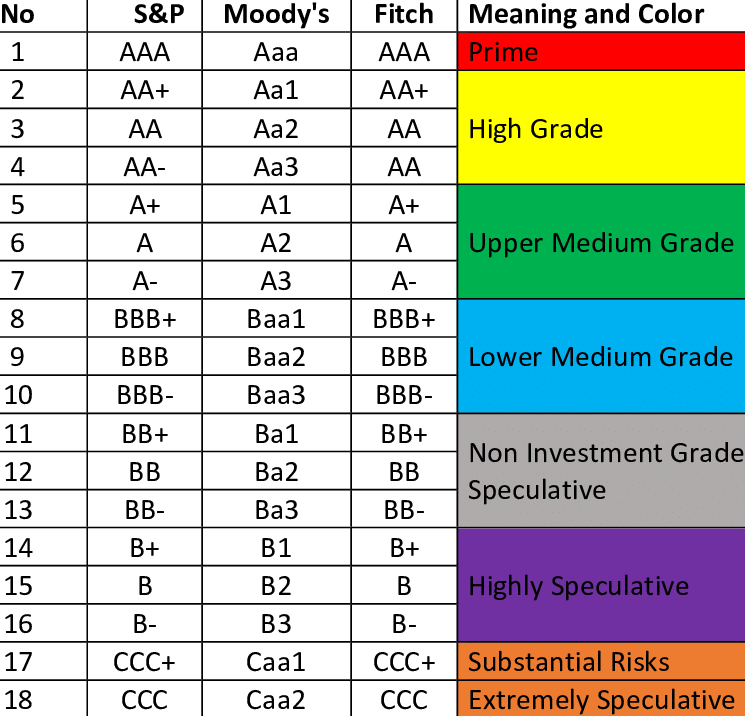

# AC y KOF Bonos


In [96]:
ac_kof_bonds = final_bonds_data_df.copy()

ac_kof_bonds = ac_kof_bonds[
    ac_kof_bonds['Organization Ultimate Parent'].isin(['Arca Continental SAB de CV']) |
    ac_kof_bonds['Issuer Name'].isin(['COCA-COLA FEMSA SAB DE CV'])
]
ac_kof_bonds = ac_kof_bonds[ac_kof_bonds['years_to_maturity'].between(3, 7)]
ac_kof_bonds = ac_kof_bonds[ac_kof_bonds['Is Callable'] == 'N']

ac_kof_bonds


,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,Call Price,Yield to Call,Yield to Worst,Yield To Maturity,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,final_flat_price
128,MX91KO0000J2,COCA-COLA FEMSA SAB DE CV,Mexico (United Mexican States) (Government),Energy,Energy - Fossil Fuels,Oil & Gas,100,NaN,100.000000,100.000000,...,NaN,<NA>,8.938639,NaN,N,<NA>,C,1863.0,5.100616,100.000000
290,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,106.36,106.411897,110.351897,...,NaN,<NA>,8.091555,8.499041,N,<NA>,<NA>,2219.0,6.075291,106.411897
291,MX91AC1J0071,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,NaN,101.176779,101.749223,...,NaN,<NA>,8.675496,NaN,N,<NA>,<NA>,2522.0,6.904860,101.176779
476,MX91KO0000J2,COCA-COLA FEMSA SAB DE CV,Mexico (United Mexican States) (Government),Energy,Energy - Fossil Fuels,Oil & Gas,100,NaN,100.000000,100.000000,...,NaN,<NA>,8.938639,NaN,N,<NA>,C,1863.0,5.100616,100.000000


In [97]:
x = ac_kof_bonds["years_to_maturity"]

ac_kof_bonds["rf_interpolated_rate"] = np.where(
    (x >= 3) & (x < 5),
    calc_linear_interpolation(3, bond_mx_3_rate, 5, bond_mx_5_rate, x),
    np.where(
        (x >=  5) & (x <= 10),
        calc_linear_interpolation(5, bond_mx_5_rate, 10, bond_mx_10_rate, x), np.nan)) * 100

ac_kof_bonds["ytm_calc"] = ac_kof_bonds.apply(
    lambda row: (
        pd.NA if row[["final_flat_price", "Coupon Rate", "Coupon Frequency",
                      "Issue Date", "Maturity Date"]].isna().any()
        else calc_ytm(
            row["final_flat_price"],
            row["Coupon Rate"],
            row["Coupon Frequency"],
            row["Issue Date"],
            row["Maturity Date"]
        )[0]
    ),
    axis=1
) * 100

# spread
ac_kof_bonds['spread'] = ac_kof_bonds['Yield To Maturity'] - ac_kof_bonds['rf_interpolated_rate']
ac_kof_bonds['spread_calc'] = ac_kof_bonds['ytm_calc'] - ac_kof_bonds['rf_interpolated_rate']

ac_kof_bonds

,Instrument,Issuer Name,Organization Ultimate Parent,TRBC Economic Sector Name,TRBC Business Sector Name,TRBC Industry Group Name,Par Value,Price,Clean Price,Dirty Price,...,ESG Bond Flag,ESG Bond Type,ESG Score Grade,days_to_maturity,years_to_maturity,final_flat_price,rf_interpolated_rate,ytm_calc,spread,spread_calc
128,MX91KO0000J2,COCA-COLA FEMSA SAB DE CV,Mexico (United Mexican States) (Government),Energy,Energy - Fossil Fuels,Oil & Gas,100,NaN,100.000000,100.000000,...,N,<NA>,C,1863.0,5.100616,100.000000,8.132459,9.187615,NaN,1.055156
290,MX91AC1J0048,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,106.36,106.411897,110.351897,...,N,<NA>,<NA>,2219.0,6.075291,106.411897,8.280991,8.666953,0.21805,0.385962
291,MX91AC1J0071,AC BEBIDAS S DE RL DE CV,Arca Continental SAB de CV,Consumer Non-Cyclicals,Food & Beverages,Beverages,100,NaN,101.176779,101.749223,...,N,<NA>,<NA>,2522.0,6.904860,101.176779,8.407410,8.917912,NaN,0.510502
476,MX91KO0000J2,COCA-COLA FEMSA SAB DE CV,Mexico (United Mexican States) (Government),Energy,Energy - Fossil Fuels,Oil & Gas,100,NaN,100.000000,100.000000,...,N,<NA>,C,1863.0,5.100616,100.000000,8.132459,9.187615,NaN,1.055156


In [95]:
number = 1

clean = ac_kof_bonds["Clean Price"].iloc[number]
coupon = ac_kof_bonds["Coupon Rate"].iloc[number]
freq = ac_kof_bonds["Coupon Frequency"].iloc[number]
issue = ac_kof_bonds["Issue Date"].iloc[number]
mat = ac_kof_bonds["Maturity Date"].iloc[number]

calc_ytm(clean, coupon, freq, issue, mat)

(0.08666952651840795,
 [np.float64(-110.43398033333332),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(4.979722222222222),
  np.float64(104.97972222222222)],
 [Timestamp('2026-03-02 00:00:00'),
  Timestamp('2026-04-06 00:00:00'),
  Timestamp('2026-10-05 00:00:00'),
  Timestamp('2027-04-05 00:00:00'),
  Timestamp('2027-10-04 00:00:00'),
  Timestamp('2028-04-03 00:00:00'),
  Timestamp('2028-10-02 00:00:00'),
  Timestamp('2029-04-02 00:00:00'),
  Timestamp('2029-10-01 00:00:00'),
  Timestamp('2030-04-01 00:00:00'),
  Timestamp('2030-09-30 00:00:00'),
  Timestamp('2031-03-31 00:00:00'),
  Timestamp('2031-09-29 00:00:00'),
  Timestamp('2032-03-29 00:00:00')])

In [98]:
ac_kof_bonds.to_excel('AC_and_KOF_bonds_mar2026.xlsx')

In [129]:
green_bonds = final_bonds_data_df.copy()

green_bonds = green_bonds[green_bonds['years_to_maturity'].between(3, 7)]
green_bonds = green_bonds[green_bonds['Is Callable'] == 'N']
green_bonds = green_bonds[green_bonds['ESG Bond Flag'] == 'Y']

green_bonds['Issuer Fitch Long Rating'].value_counts()

Issuer Fitch Long Rating
BB+     6
BBB-    2
Name: count, dtype: Int64

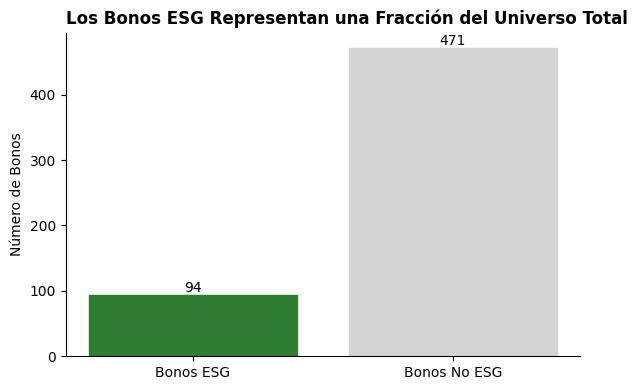

In [ ]:
green_bonds = final_bonds_data_df.copy()

counts = green_bonds["ESG Bond Flag"].value_counts()

esg = counts.get("Y", 0)
no_esg = counts.get("N", 0)

plt.figure(figsize=(6, 4))

bars = plt.bar(
    ["Bonos ESG", "Bonos No ESG"],
    [esg, no_esg]
)

bars[0].set_color("#2E7D32")   # verde ESG
bars[1].set_color("#D3D3D3")   # gris neutro

ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(False)

for i, v in enumerate([esg, no_esg]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

plt.title(
    "Los Bonos ESG Representan una Fracción del Universo Total",
    loc="left",
    fontsize=12,
    weight="bold"
)

plt.ylabel("Número de Bonos")

plt.tight_layout()
plt.show()

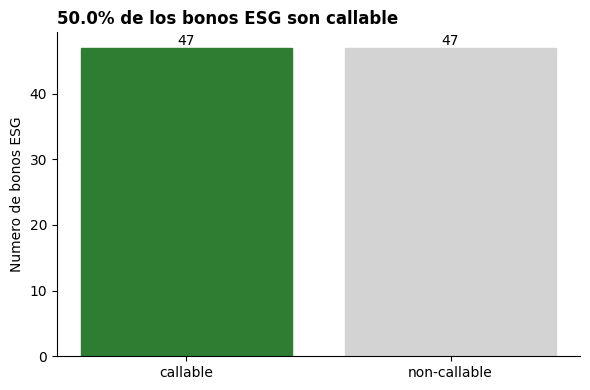

In [ ]:
# filter only esg bonds
esg_bonds = final_bonds_data_df[
    final_bonds_data_df["ESG Bond Flag"] == "Y"
]

# count callable vs non-callable inside esg
callable_counts = esg_bonds["Is Callable"].value_counts()

callable_yes = callable_counts.get("Y", 0)
callable_no = callable_counts.get("N", 0)

# compute total and percentage
total_esg = callable_yes + callable_no
pct_callable = callable_yes / total_esg if total_esg > 0 else 0


plt.figure(figsize=(6, 4))

# create bar chart
bars = plt.bar(
    ["callable", "non-callable"],
    [callable_yes, callable_no]
)

# highlight callable in green
bars[0].set_color("#2E7D32")
bars[1].set_color("#D3D3D3")

# remove unnecessary chart elements
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.grid(False)

# add direct value labels
for i, v in enumerate([callable_yes, callable_no]):
    plt.text(i, v, f"{v:,}", ha="center", va="bottom")

# add storytelling title
plt.title(
    f"{pct_callable:.1%} de los bonos ESG son callable",
    loc="left",
    fontsize=12,
    weight="bold"
)

plt.ylabel("Numero de bonos ESG")

plt.tight_layout()
plt.show()